In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [2]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
 
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

In [3]:
df = pd.read_excel("C:/Users/TANZEEM/Desktop/ed-feed project/datasetpreprocessing/edfeed_clean_data.xlsx")
LABEL_ORDER = ['Positive', 'Neutral', 'Negative']
RANDOM_STATE = 42

In [4]:
print("ED-FEED — CLASS IMBALANCE CORRECTION")
print("Positive 59% | Neutral 12.5% | Negative 28.4%")

ED-FEED — CLASS IMBALANCE CORRECTION
Positive 59% | Neutral 12.5% | Negative 28.4%


# STEP 1 — LOAD & PREPARE DATA

In [5]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
 
df['student_star']      = df['student_star'].fillna(df['student_star'].median())
df['student_difficult'] = df['student_difficult'].fillna(df['student_difficult'].median())
df['comments']          = df['comments'].fillna('')
df['word_comment']      = df['word_comment'].fillna(0)
df['take_again']        = df['take_again'].fillna(df['take_again'].median())
df['tag_professor']     = df['tag_professor'].fillna('No Tag')
for col in ['attence', 'for_credits', 'would_take_agains', 'grades']:
    df[col] = df[col].fillna('Not Reported')
 
def iqr_cap(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    return series.clip(Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1))
 
for col in ['star_rating','student_star','student_difficult',
            'diff_index','num_student','word_comment']:
    df[col] = iqr_cap(df[col])
 
def get_sentiment(star):
    if star >= 4.0: return 'Positive'
    if star >= 3.0: return 'Neutral'
    return 'Negative'
 
df['sentiment_label'] = df['student_star'].apply(get_sentiment)
df = df[df['comments'] != ''].reset_index(drop=True)
 
TEXT_COL = 'comments'
y        = df['sentiment_label']
dist     = y.value_counts()
 
print(f"  Source      : RateMyProfessor_Sample_data.xlsx")
print(f"  Text column : '{TEXT_COL}'   your notebook column")
print(f"  Total rows  : {len(df):,}")
for l in LABEL_ORDER:
    n = dist.get(l, 0)
    print(f"  {l:<10} : {n:>6,}  ({n/len(df)*100:.1f}%)")


  Source      : RateMyProfessor_Sample_data.xlsx
  Text column : 'comments'   your notebook column
  Total rows  : 19,977
  Positive   : 11,803  (59.1%)
  Neutral    :  2,505  (12.5%)
  Negative   :  5,669  (28.4%)


In [6]:
print(df.columns )

Index(['professor_name', 'school_name', 'department_name', 'local_name',
       'state_name', 'year_since_first_review', 'star_rating', 'take_again',
       'diff_index', 'tag_professor', 'num_student', 'post_date',
       'name_onlines', 'name_not_onlines', 'student_star', 'student_difficult',
       'attence', 'for_credits', 'would_take_agains', 'grades', 'help_useful',
       'help_not_useful', 'comments', 'word_comment', 'gender', 'race',
       'asian', 'hispanic', 'nh_black', 'nh_white', 'gives_good_feedback',
       'caring', 'respected', 'participation_matters',
       'clear_grading_criteria', 'skip_class', 'amazing_lectures',
       'inspirational', 'tough_grader', 'hilarious', 'get_ready_to_read',
       'lots_of_homework', 'accessible_outside_class', 'lecture_heavy',
       'extra_credit', 'graded_by_few_things', 'group_projects', 'test_heavy',
       'so_many_papers', 'beware_of_pop_quizzes', 'IsCourseOnline',
       'post_year', 'post_month', 'date_missing_flag', 'grade_g

# STEP 2 — DUMMY CLASSIFIER BASELINE

In [7]:
majority_acc = dist['Positive'] / len(df)
print(f"\n[STEP 2] Dummy classifier baseline …")
print(f"  Always predicting 'Positive' {majority_acc*100:.1f}% accuracy with ZERO learning.")
print(f"  Any model near this accuracy is essentially a dummy model.")
print(f"  Use Macro F1 as primary metric, not accuracy.")


[STEP 2] Dummy classifier baseline …
  Always predicting 'Positive' 59.1% accuracy with ZERO learning.
  Any model near this accuracy is essentially a dummy model.
  Use Macro F1 as primary metric, not accuracy.


# STEP 3 — TRAIN / TEST SPLIT  (stratified, done ONCE before any resampling)

In [8]:
print("    Resampling is ONLY applied to the train set.")
print("     Test set is never touched — it reflects the real distribution.")

    Resampling is ONLY applied to the train set.
     Test set is never touched — it reflects the real distribution.


In [9]:
X_raw = df[TEXT_COL].astype(str)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [10]:
print(f"  Train : {len(X_train_raw):,}  |  Test : {len(X_test_raw):,}")
for l in LABEL_ORDER:
    n = (y_train == l).sum()
    print(f"    {l:<10}: {n:>5,}  ({n/len(y_train)*100:.1f}%)")

  Train : 15,981  |  Test : 3,996
    Positive  : 9,442  (59.1%)
    Neutral   : 2,004  (12.5%)
    Negative  : 4,535  (28.4%)


# STEP 4 — SHARED TF-IDF (fit on train only, transform both)

In [11]:
tfidf     = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train_v = tfidf.fit_transform(X_train_raw)
X_test_v  = tfidf.transform(X_test_raw)
print(f"  Matrix: {X_train_v.shape[0]:,} × {X_train_v.shape[1]:,} features")

  Matrix: 15,981 × 5,000 features


# STEP 5 — 5 STRATEGIES

In [12]:
strategies = {
    'S1': {'name':'S1 · Class Weight',       'sampler':None,
           'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                       class_weight='balanced')},
    'S2': {'name':'S2 · Random Oversample',  'sampler':RandomOverSampler(random_state=RANDOM_STATE),
           'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)},
    'S3': {'name':'S3 · SMOTE',              'sampler':SMOTE(random_state=RANDOM_STATE, k_neighbors=3),
           'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)},
    'S4': {'name':'S4 · Random Undersample', 'sampler':RandomUnderSampler(random_state=RANDOM_STATE),
           'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)},
    'S5': {'name':'S5 · SMOTE + Tomek',      'sampler':SMOTETomek(random_state=RANDOM_STATE),
           'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)},
}

# STEP 6 — TRAIN & EVALUATE

In [13]:
print("PRIMARY metric : Macro F1\n")
 
results = {}
for key, cfg in strategies.items():
    print(f"  ── {cfg['name']} ──────────────────────────")
    sampler = cfg['sampler']
    model   = cfg['model']
 
    if sampler is not None:
        try:
            X_res, y_res = sampler.fit_resample(X_train_v, y_train)
        except Exception as e:
            print(f" Sampler error ({e})  class_weight fallback")
            X_res, y_res = X_train_v, y_train
            model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                       class_weight='balanced')
    else:
        X_res, y_res = X_train_v, y_train
 
    res_dist = pd.Series(y_res).value_counts()
    print(f"     Resampled train  ", end='')
    for l in LABEL_ORDER:
        print(f"{l}: {res_dist.get(l,0):,}", end='  ')
    print()

PRIMARY metric : Macro F1

  ── S1 · Class Weight ──────────────────────────
     Resampled train  Positive: 9,442  Neutral: 2,004  Negative: 4,535  
  ── S2 · Random Oversample ──────────────────────────
     Resampled train  Positive: 9,442  Neutral: 9,442  Negative: 9,442  
  ── S3 · SMOTE ──────────────────────────
     Resampled train  Positive: 9,442  Neutral: 9,442  Negative: 9,442  
  ── S4 · Random Undersample ──────────────────────────
     Resampled train  Positive: 2,004  Neutral: 2,004  Negative: 2,004  
  ── S5 · SMOTE + Tomek ──────────────────────────
     Resampled train  Positive: 9,424  Neutral: 9,439  Negative: 9,421  


In [ ]:
model.fit(X_res, y_res)
y_pred   = model.predict(X_test_v)
acc      = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro',    labels=LABEL_ORDER)
wtd_f1   = f1_score(y_test, y_pred, average='weighted', labels=LABEL_ORDER)
rpt_dict = classification_report(y_test, y_pred, labels=LABEL_ORDER, output_dict=True)
rpt_str  = classification_report(y_test, y_pred, labels=LABEL_ORDER)
cm       = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
 
results[key] = dict(name=cfg['name'], model=model, y_pred=y_pred,
                        accuracy=acc, macro_f1=macro_f1, wtd_f1=wtd_f1,
                        report=rpt_dict, report_str=rpt_str,
                        cm=cm, res_dist=res_dist)
 
print(f"     Accuracy : {acc:.4f}  |  Macro F1 : {macro_f1:.4f}   PRIMARY")
for l in LABEL_ORDER:
        r = rpt_dict[l]
        print(f"       {l:<10}  P:{r['precision']:.3f}  R:{r['recall']:.3f}  F1:{r['f1-score']:.3f}")
print()
 

# STEP 7 — 5-FOLD CROSS VALIDATION

In [ ]:
best_key = max(results, key=lambda k: results[k]['macro_f1'])
best_cfg = strategies[best_key]
 
print(f"\n[STEP 7] 5-Fold Stratified CV  best: {results[best_key]['name']}\n")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_accs, cv_f1s = [], []
 
for fold_n, (tr_idx, val_idx) in enumerate(skf.split(X_train_v, y_train), 1):
    Xf_tr, yf_tr   = X_train_v[tr_idx], np.array(y_train)[tr_idx]
    Xf_val, yf_val = X_train_v[val_idx], np.array(y_train)[val_idx]
 
    sp = best_cfg['sampler']
    if sp is not None:
        try:   Xf_tr, yf_tr = sp.fit_resample(Xf_tr, yf_tr)
        except: pass
 
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                             class_weight='balanced' if sp is None else None)
    clf.fit(Xf_tr, yf_tr)
    yf_pred = clf.predict(Xf_val)
 
    fa = accuracy_score(yf_val, yf_pred)
    ff = f1_score(yf_val, yf_pred, average='macro', labels=LABEL_ORDER)
    cv_accs.append(fa); cv_f1s.append(ff)
    print(f"    Fold {fold_n}: Accuracy {fa:.4f}  |  Macro F1 {ff:.4f}")
 
cv_acc_mean, cv_acc_std = np.mean(cv_accs), np.std(cv_accs)
cv_f1_mean,  cv_f1_std  = np.mean(cv_f1s),  np.std(cv_f1s)
test_f1 = results[best_key]['macro_f1']
gap     = abs(cv_f1_mean - test_f1)
 
print(f"\n  CV Accuracy  : {cv_acc_mean:.4f} ± {cv_acc_std:.4f}")
print(f"  CV Macro F1  : {cv_f1_mean:.4f}  ± {cv_f1_std:.4f}")
print(f"  Test Macro F1: {test_f1:.4f}")
print(f"  Gap          : {gap:.4f}   ", end='')
print(" No overfitting" if gap < 0.03 else (" Mild variance" if gap < 0.06 else "Overfitting"))


[STEP 7] 5-Fold Stratified CV  best: S5 · SMOTE + Tomek

    Fold 1: Accuracy 0.7063  |  Macro F1 0.5975
    Fold 2: Accuracy 0.7115  |  Macro F1 0.6107
    Fold 3: Accuracy 0.7068  |  Macro F1 0.5956
    Fold 4: Accuracy 0.7078  |  Macro F1 0.5980
    Fold 5: Accuracy 0.6924  |  Macro F1 0.5813

  CV Accuracy  : 0.7050 ± 0.0065
  CV Macro F1  : 0.5966  ± 0.0094
  Test Macro F1: 0.5936
  Gap          : 0.0030    No overfitting


# STEP 8 — COMPARISON TABLE

In [ ]:
print(f"  {'Strategy':<28} {'Accuracy':>10} {'Macro F1':>10} {'Wtd F1':>9} "
      f"{'Neu F1':>9} {'Pos F1':>9} {'Neg F1':>9}")
print("  " + "─"*87)
for key, res in results.items():
    r    = res['report']
    mark = "   BEST" if key == best_key else ""
    print(f"  {res['name']:<28} {res['accuracy']:>10.4f} {res['macro_f1']:>10.4f} "
          f"{res['wtd_f1']:>9.4f} {r['Neutral']['f1-score']:>9.4f} "
          f"{r['Positive']['f1-score']:>9.4f} {r['Negative']['f1-score']:>9.4f}{mark}")
print(f"\n  Dummy baseline (always Positive): {majority_acc*100:.1f}% accuracy, Macro F1 ≈ 0.33")

  Strategy                       Accuracy   Macro F1    Wtd F1    Neu F1    Pos F1    Neg F1
  ───────────────────────────────────────────────────────────────────────────────────────
  S5 · SMOTE + Tomek               0.7027     0.5936    0.7099    0.2646    0.8027    0.7135   BEST

  Dummy baseline (always Positive): 59.1% accuracy, Macro F1 ≈ 0.33


# STEP 9 — VISUALISATIONS

In [ ]:
BAR_SENT     = {'Positive':'#3ecf8e','Neutral':'#f5a623','Negative':'#f56b6b'}
COLORS_STRAT = ['#5aabf5','#3ecf8e','#9d95f5','#f5a623','#f56b6b']
SHORT        = ['ClassWt','RandOver','SMOTE','RandUnder','SMOTE+Tomek']
keys_ord     = list(results.keys())
 
fig = plt.figure(figsize=(22, 20))
fig.suptitle(
    f"ED-FEED — Class Imbalance Correction: 5-Strategy Comparison\n"
    f"Text column: '{TEXT_COL}'  |  Primary metric: Macro F1",
    fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.38)
 

<Figure size 2200x2000 with 0 Axes>

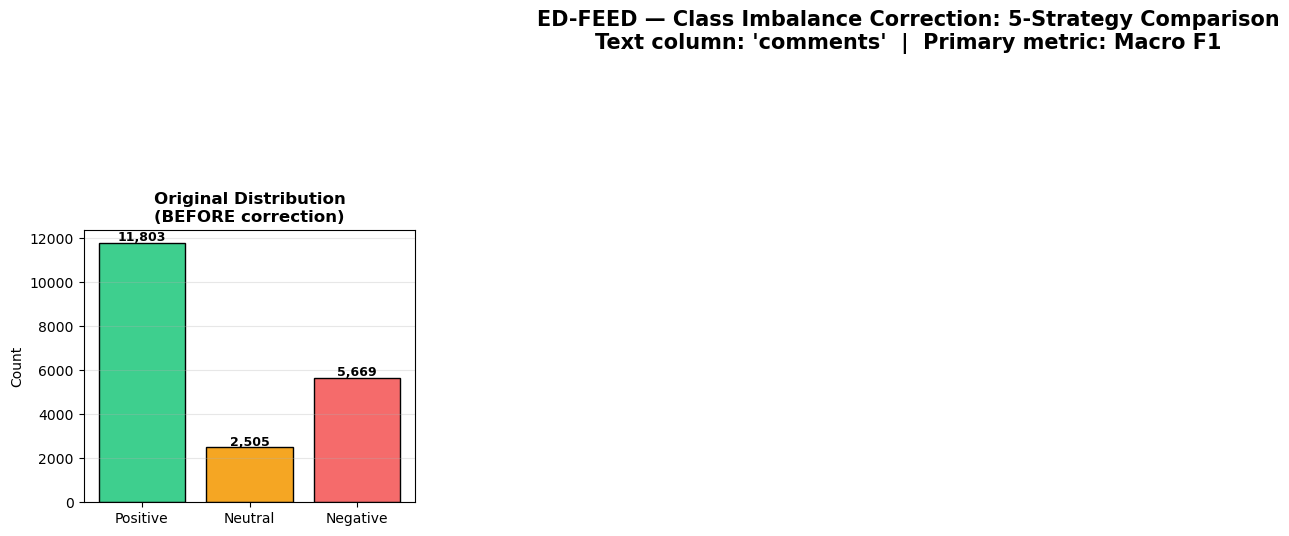

In [ ]:
ax0 = fig.add_subplot(gs[0,0])
orig = [dist.get(l,0) for l in LABEL_ORDER]
b0 = ax0.bar(LABEL_ORDER, orig, color=[BAR_SENT[l] for l in LABEL_ORDER], edgecolor='black')
ax0.set_title("Original Distribution\n(BEFORE correction)", fontweight='bold')
ax0.set_ylabel("Count")
for b, c in zip(b0, orig):
    ax0.text(b.get_x()+b.get_width()/2, b.get_height()+80, f'{c:,}', ha='center', fontsize=9, fontweight='bold')
ax0.grid(axis='y', alpha=0.3)
display(fig)

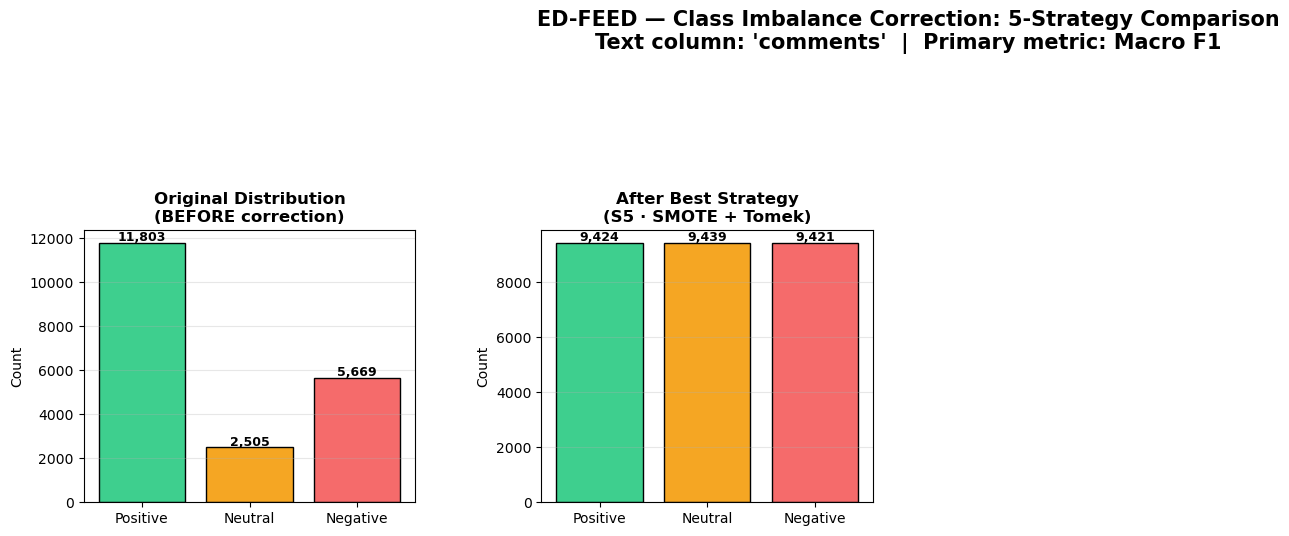

In [ ]:
ax1 = fig.add_subplot(gs[0,1])
best_c = [results[best_key]['res_dist'].get(l,0) for l in LABEL_ORDER]
b1 = ax1.bar(LABEL_ORDER, best_c, color=[BAR_SENT[l] for l in LABEL_ORDER], edgecolor='black')
ax1.set_title(f"After Best Strategy\n({results[best_key]['name']})", fontweight='bold')
ax1.set_ylabel("Count")
for b, c in zip(b1, best_c):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+80, f'{c:,}', ha='center', fontsize=9, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
display(fig)

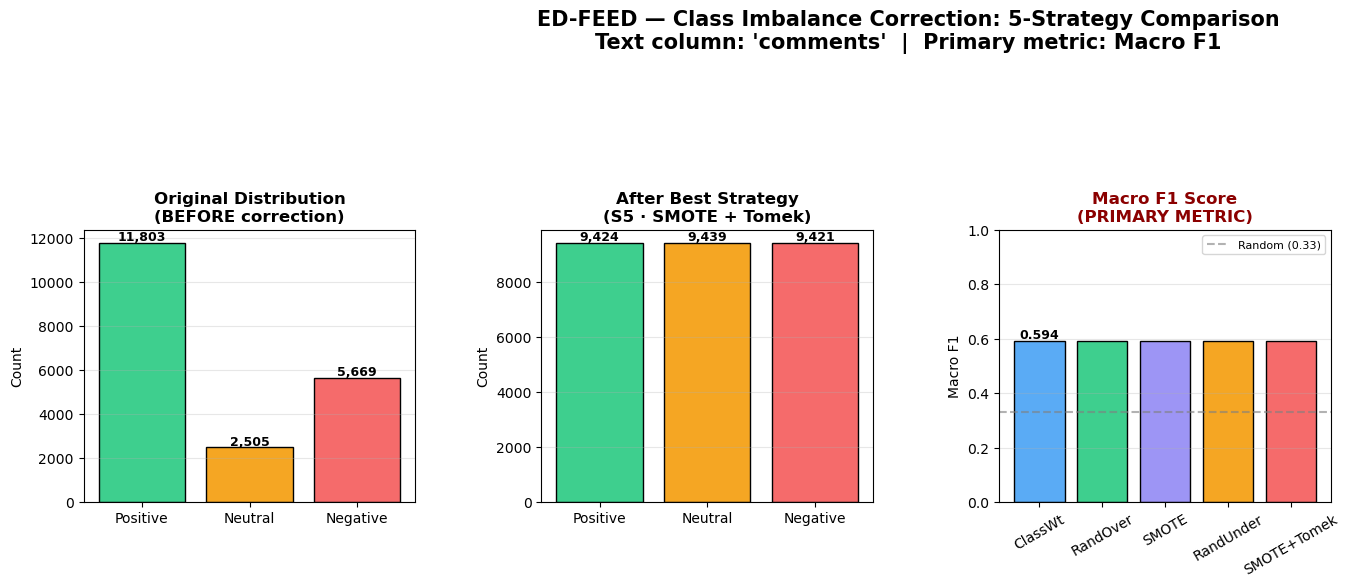

In [ ]:
ax2 = fig.add_subplot(gs[0,2])
mf1 = [results[k]['macro_f1'] for k in keys_ord]
b2  = ax2.bar(SHORT, mf1, color=COLORS_STRAT, edgecolor='black')
ax2.set_title("Macro F1 Score\n(PRIMARY METRIC)", fontweight='bold', color='darkred')
ax2.set_ylabel("Macro F1"); ax2.set_ylim([0,1.0])
ax2.axhline(0.33, color='gray', linestyle='--', alpha=0.6, label='Random (0.33)')
ax2.legend(fontsize=8)
for b, v in zip(b2, mf1):
    ax2.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.tick_params(axis='x', rotation=30); ax2.grid(axis='y', alpha=0.3)
display(fig)

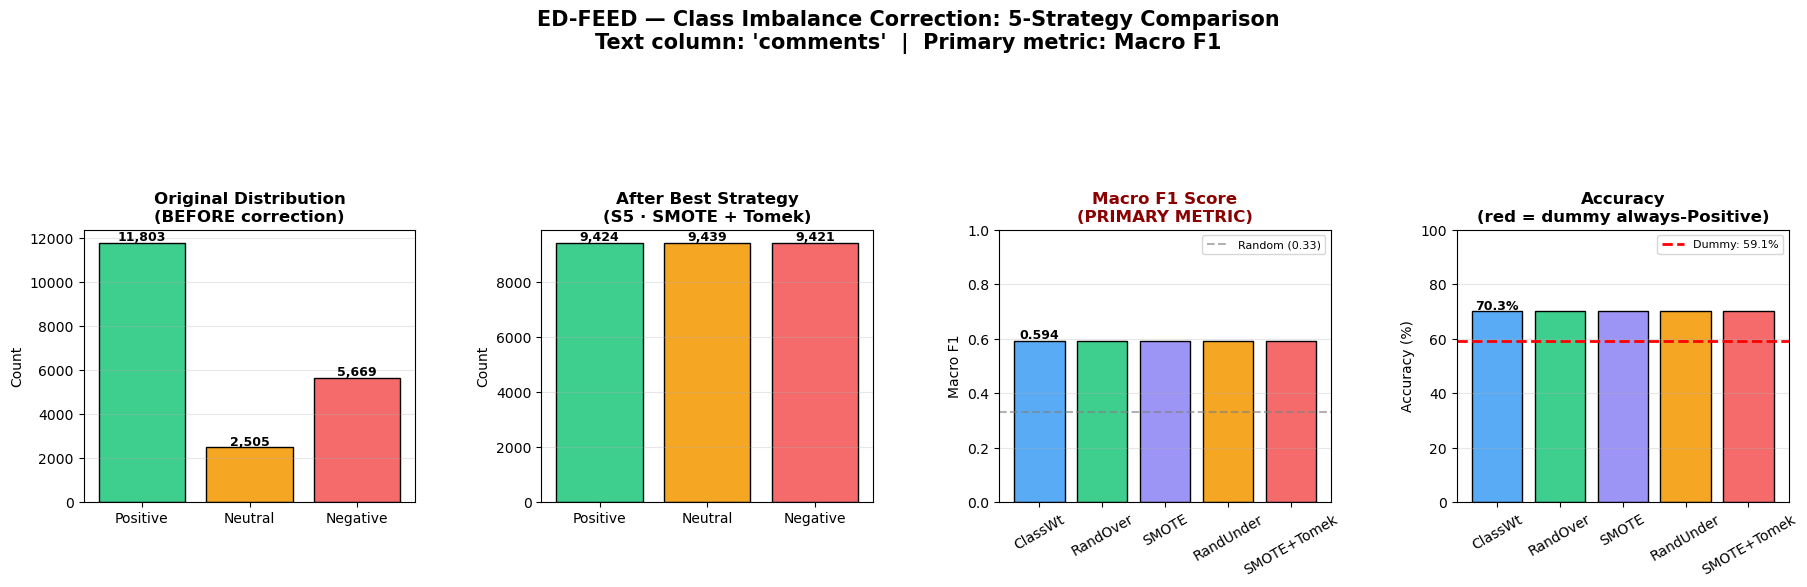

In [ ]:
ax3 = fig.add_subplot(gs[0,3])
accs = [results[k]['accuracy']*100 for k in keys_ord]
b3   = ax3.bar(SHORT, accs, color=COLORS_STRAT, edgecolor='black')
ax3.axhline(majority_acc*100, color='red', linestyle='--', linewidth=2,
            label=f'Dummy: {majority_acc*100:.1f}%')
ax3.set_title("Accuracy\n(red = dummy always-Positive)", fontweight='bold')
ax3.set_ylabel("Accuracy (%)"); ax3.set_ylim([0,100])
ax3.legend(fontsize=8)
for b, v in zip(b3, accs):
    ax3.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax3.tick_params(axis='x', rotation=30); ax3.grid(axis='y', alpha=0.3)
display(fig)

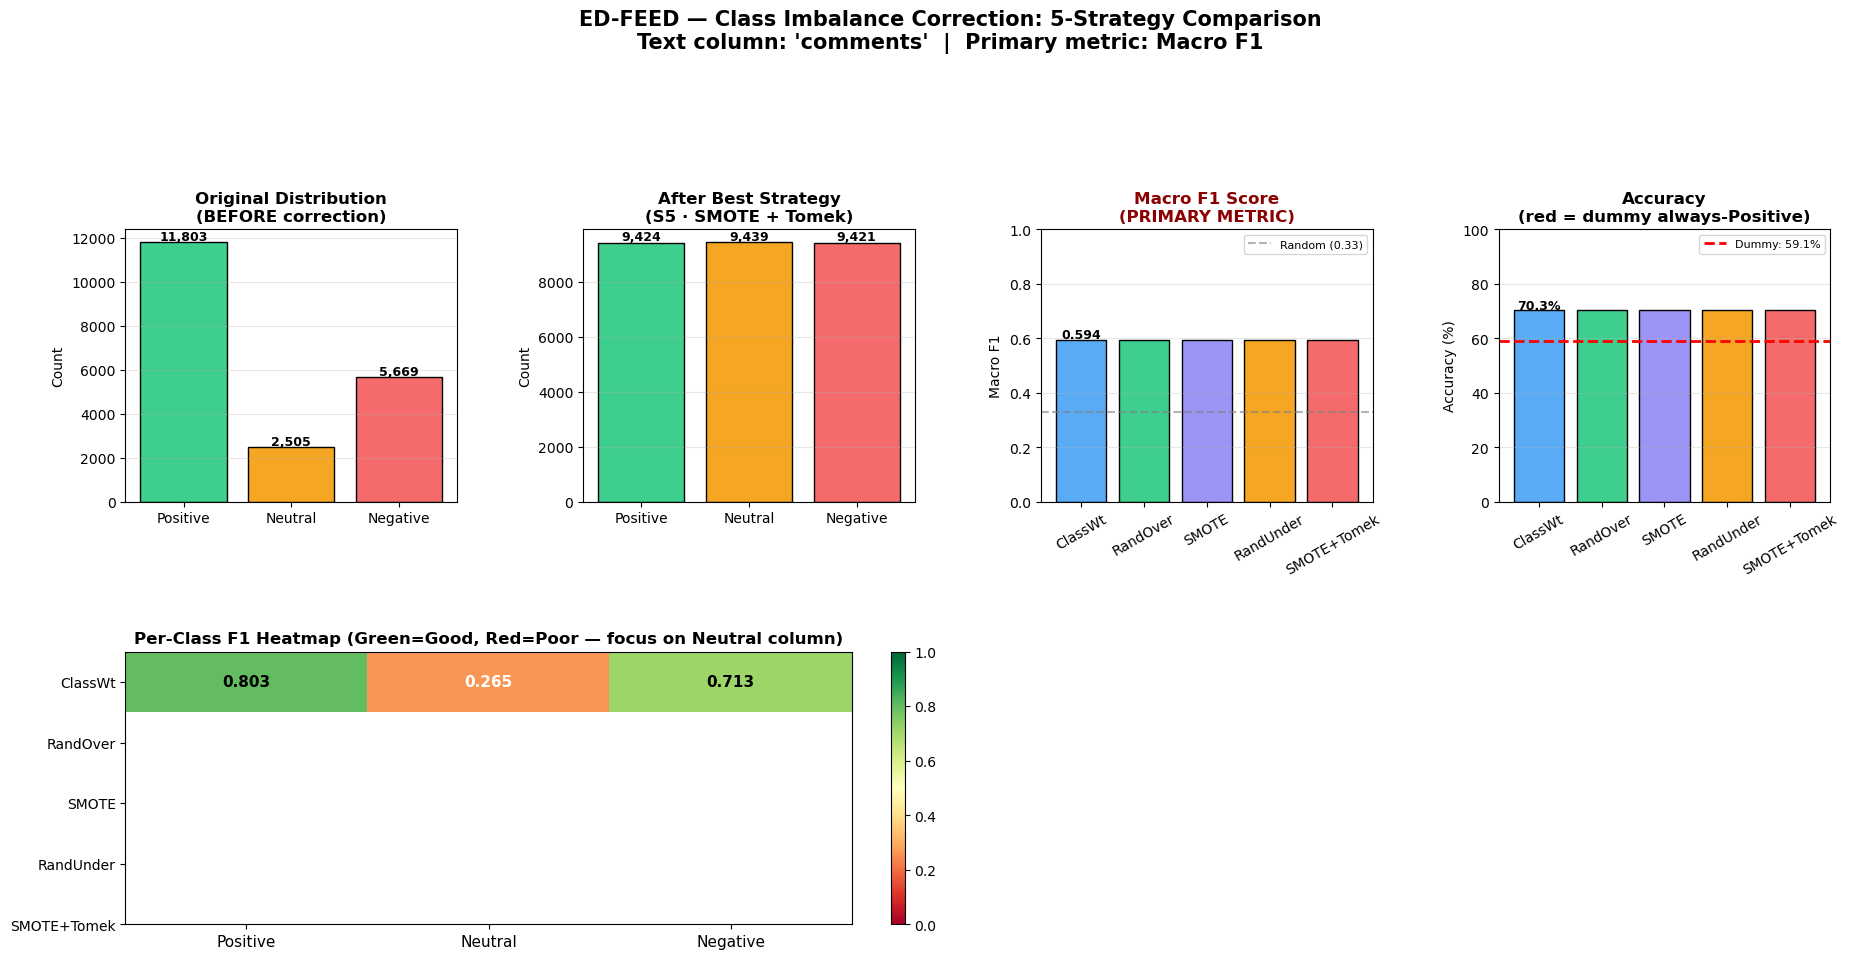

<Figure size 640x480 with 0 Axes>

In [ ]:
ax46 = fig.add_subplot(gs[1,:2])
f1m  = np.array([[results[k]['report'][l]['f1-score'] for l in LABEL_ORDER] for k in keys_ord])
im   = ax46.imshow(f1m, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax46.set_xticks(range(3)); ax46.set_xticklabels(LABEL_ORDER, fontsize=11)
ax46.set_yticks(range(5)); ax46.set_yticklabels(SHORT, fontsize=10)
for i in range(f1m.shape[0]):
    for j in range(f1m.shape[1]):
            ax46.text(j, i, f'{f1m[i,j]:.3f}', ha='center', va='center', fontsize=11,
                  fontweight='bold', color='black' if f1m[i,j]>0.5 else 'white')
ax46.set_title("Per-Class F1 Heatmap (Green=Good, Red=Poor — focus on Neutral column)", fontweight='bold')
plt.colorbar(im, ax=ax46, fraction=0.03)
display(fig)

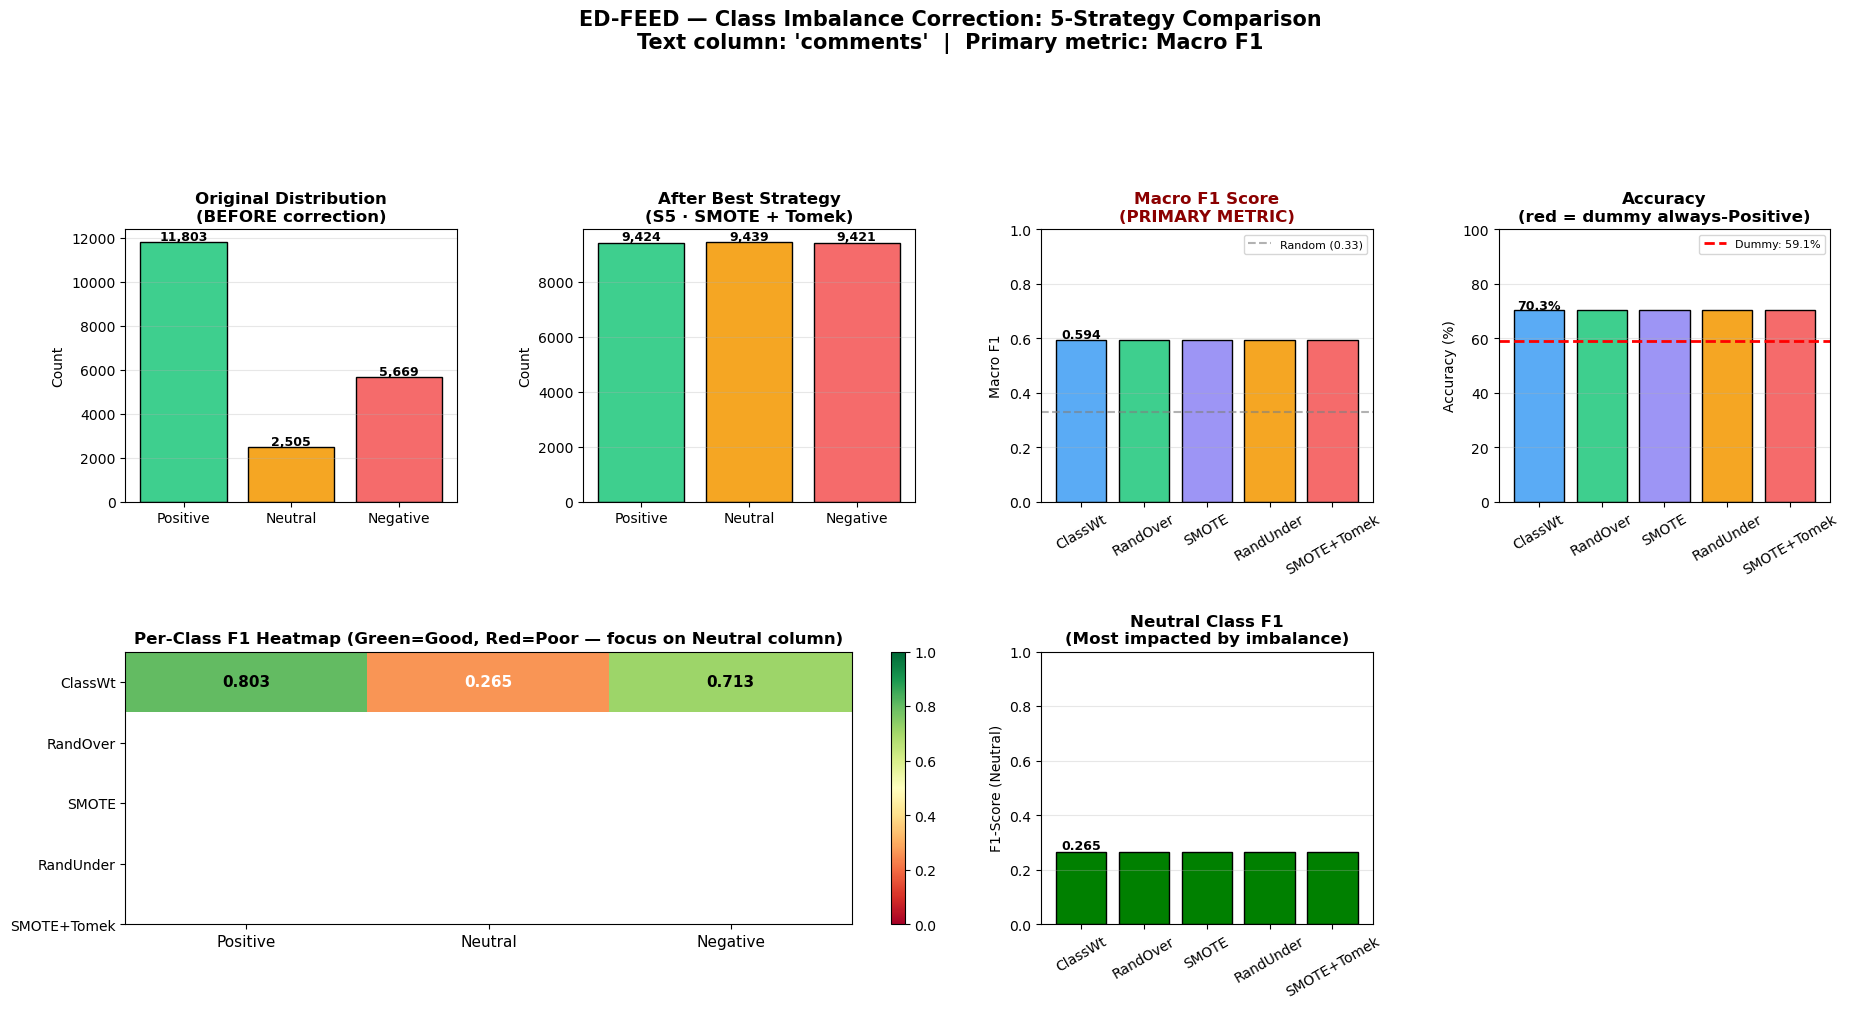

In [ ]:
ax7 = fig.add_subplot(gs[1,2])
nf1 = [results[k]['report']['Neutral']['f1-score'] for k in keys_ord]
cn  = ['green' if v==max(nf1) else 'steelblue' for v in nf1]
ax7.bar(SHORT, nf1, color=cn, edgecolor='black')
ax7.set_title("Neutral Class F1\n(Most impacted by imbalance)", fontweight='bold')
ax7.set_ylabel("F1-Score (Neutral)"); ax7.set_ylim([0,1.0])
for i, v in enumerate(nf1):
    ax7.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax7.tick_params(axis='x', rotation=30); ax7.grid(axis='y', alpha=0.3)
display(fig)

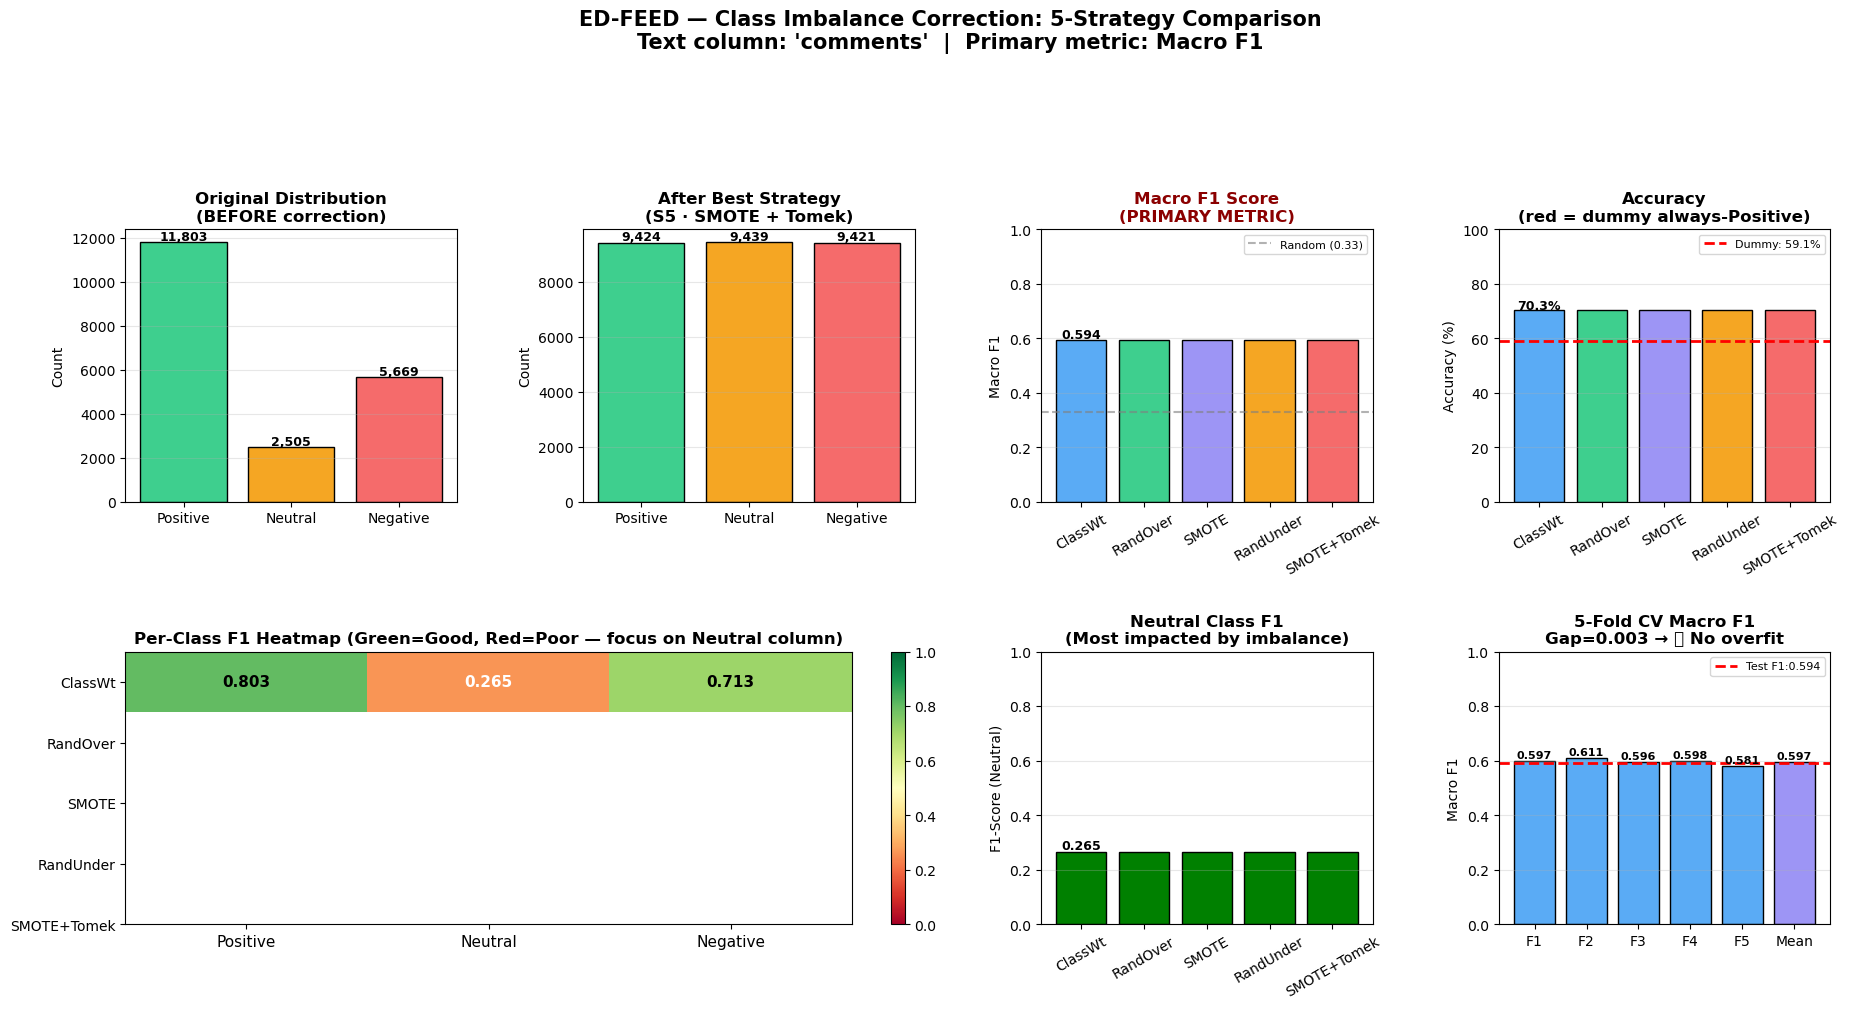

In [ ]:
ax8 = fig.add_subplot(gs[1,3])
fl  = [f'F{i}' for i in range(1,6)] + ['Mean']
cv_v = cv_f1s + [cv_f1_mean]
ax8.bar(fl, cv_v, color=['#5aabf5']*5+['#9d95f5'], edgecolor='black')
ax8.axhline(test_f1, color='red', linestyle='--', linewidth=2, label=f'Test F1:{test_f1:.3f}')
ax8.set_title(f"5-Fold CV Macro F1\nGap={gap:.3f} → {'✅ No overfit' if gap<0.03 else '⚠ Check'}", fontweight='bold')
ax8.set_ylabel("Macro F1"); ax8.set_ylim([0,1.0]); ax8.legend(fontsize=8)
for b, v in zip(ax8.patches, cv_v):
    ax8.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
ax8.grid(axis='y', alpha=0.3)
display(fig)

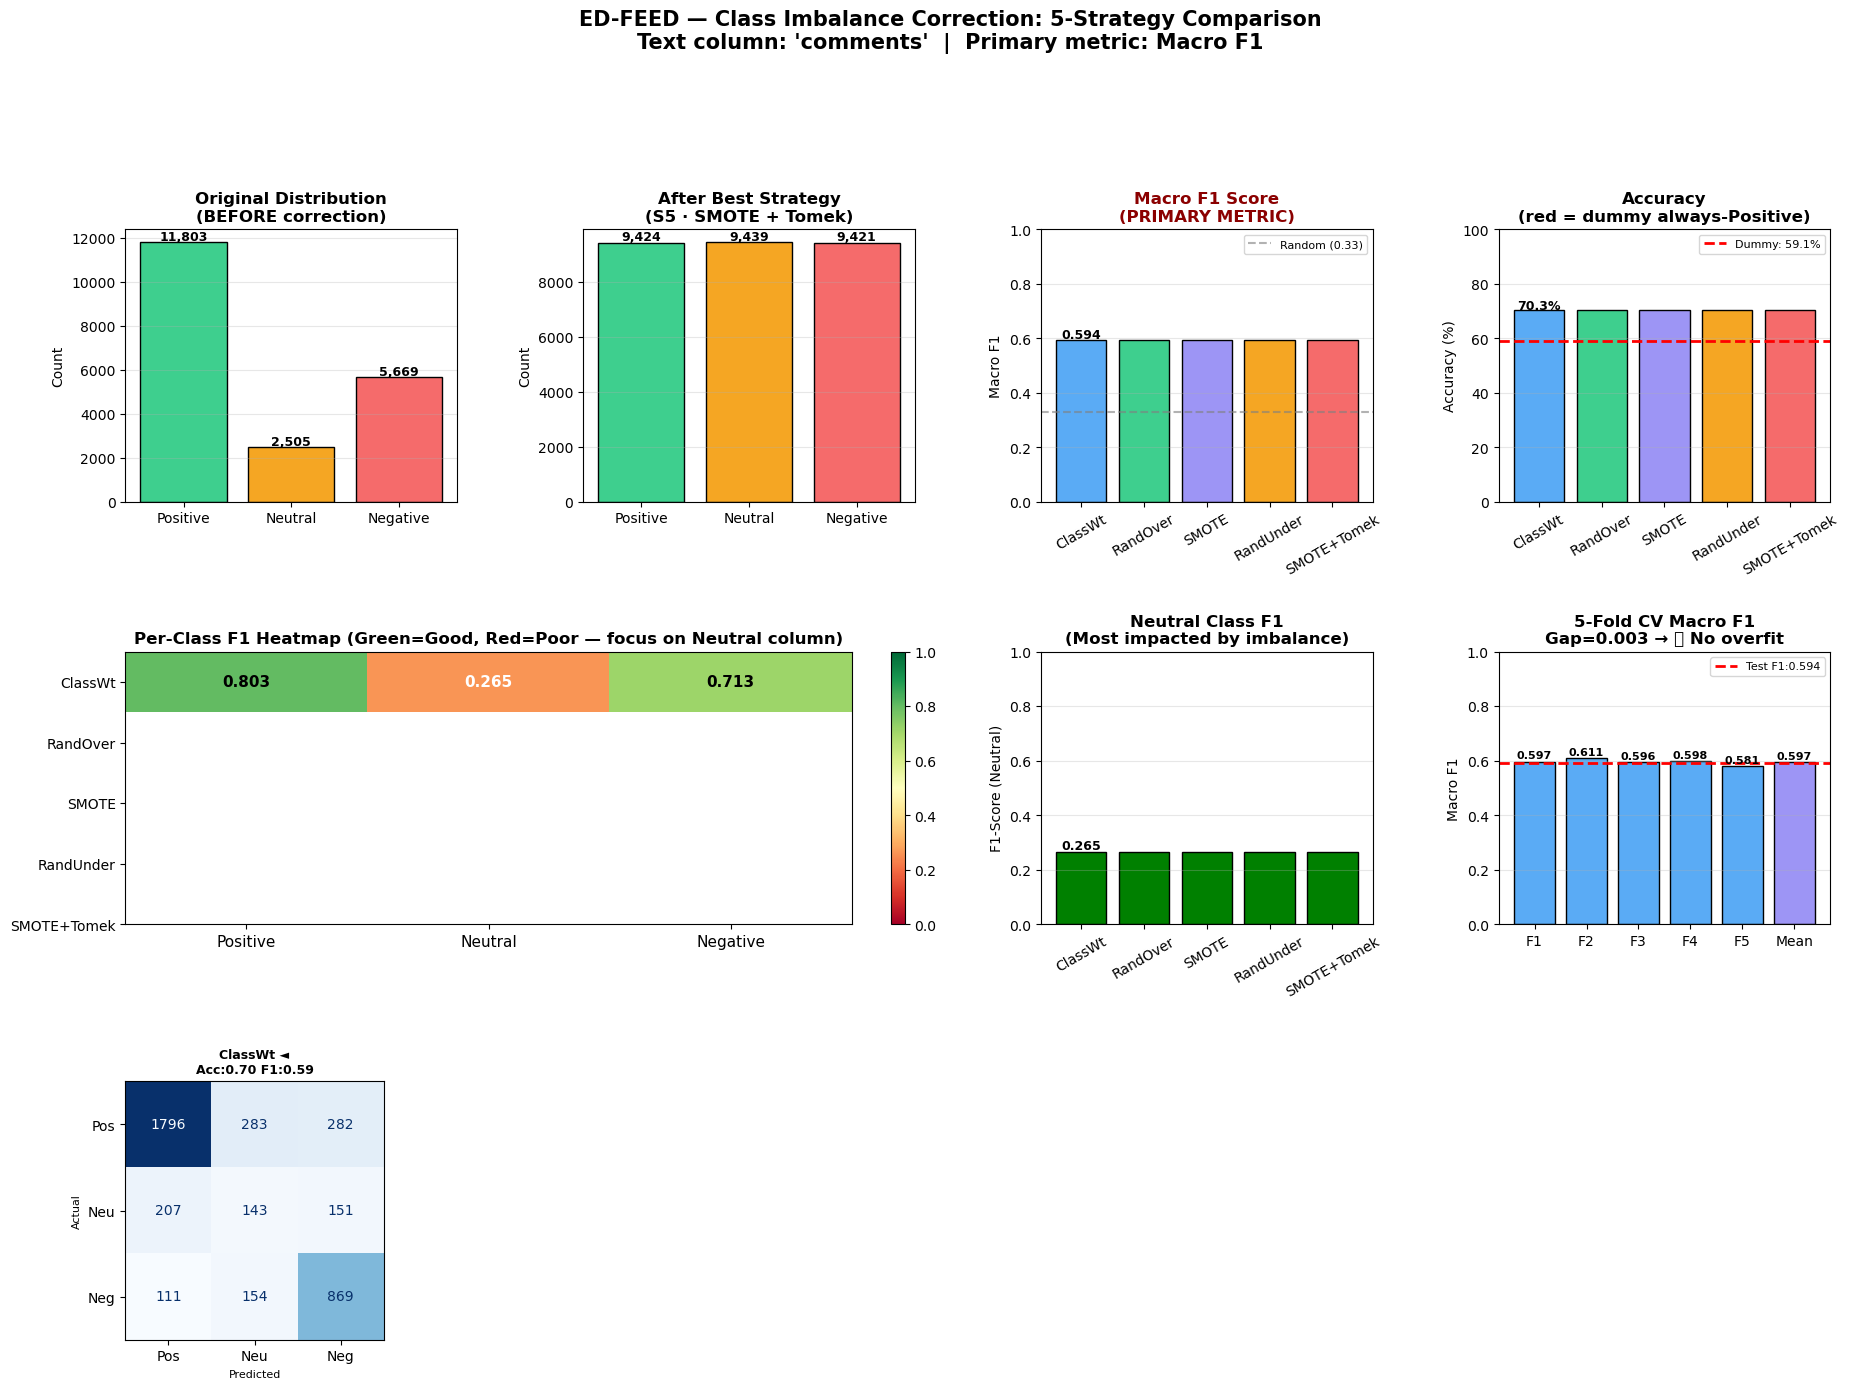

In [ ]:
gs_cm = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[2,:], wspace=0.4)
for idx, (key, res) in enumerate(results.items()):
    ax_cm = fig.add_subplot(gs_cm[idx])
    ConfusionMatrixDisplay(res['cm'], display_labels=['Pos','Neu','Neg']).plot(
        ax=ax_cm, colorbar=False, cmap=['Blues','Greens','Purples','Oranges','Reds'][idx])
    mark = " ◄" if key == best_key else ""
    ax_cm.set_title(f"{SHORT[idx]}{mark}\nAcc:{res['accuracy']:.2f} F1:{res['macro_f1']:.2f}",
                    fontsize=9, fontweight='bold')
    ax_cm.set_xlabel("Predicted", fontsize=8); ax_cm.set_ylabel("Actual", fontsize=8)
    display(fig)

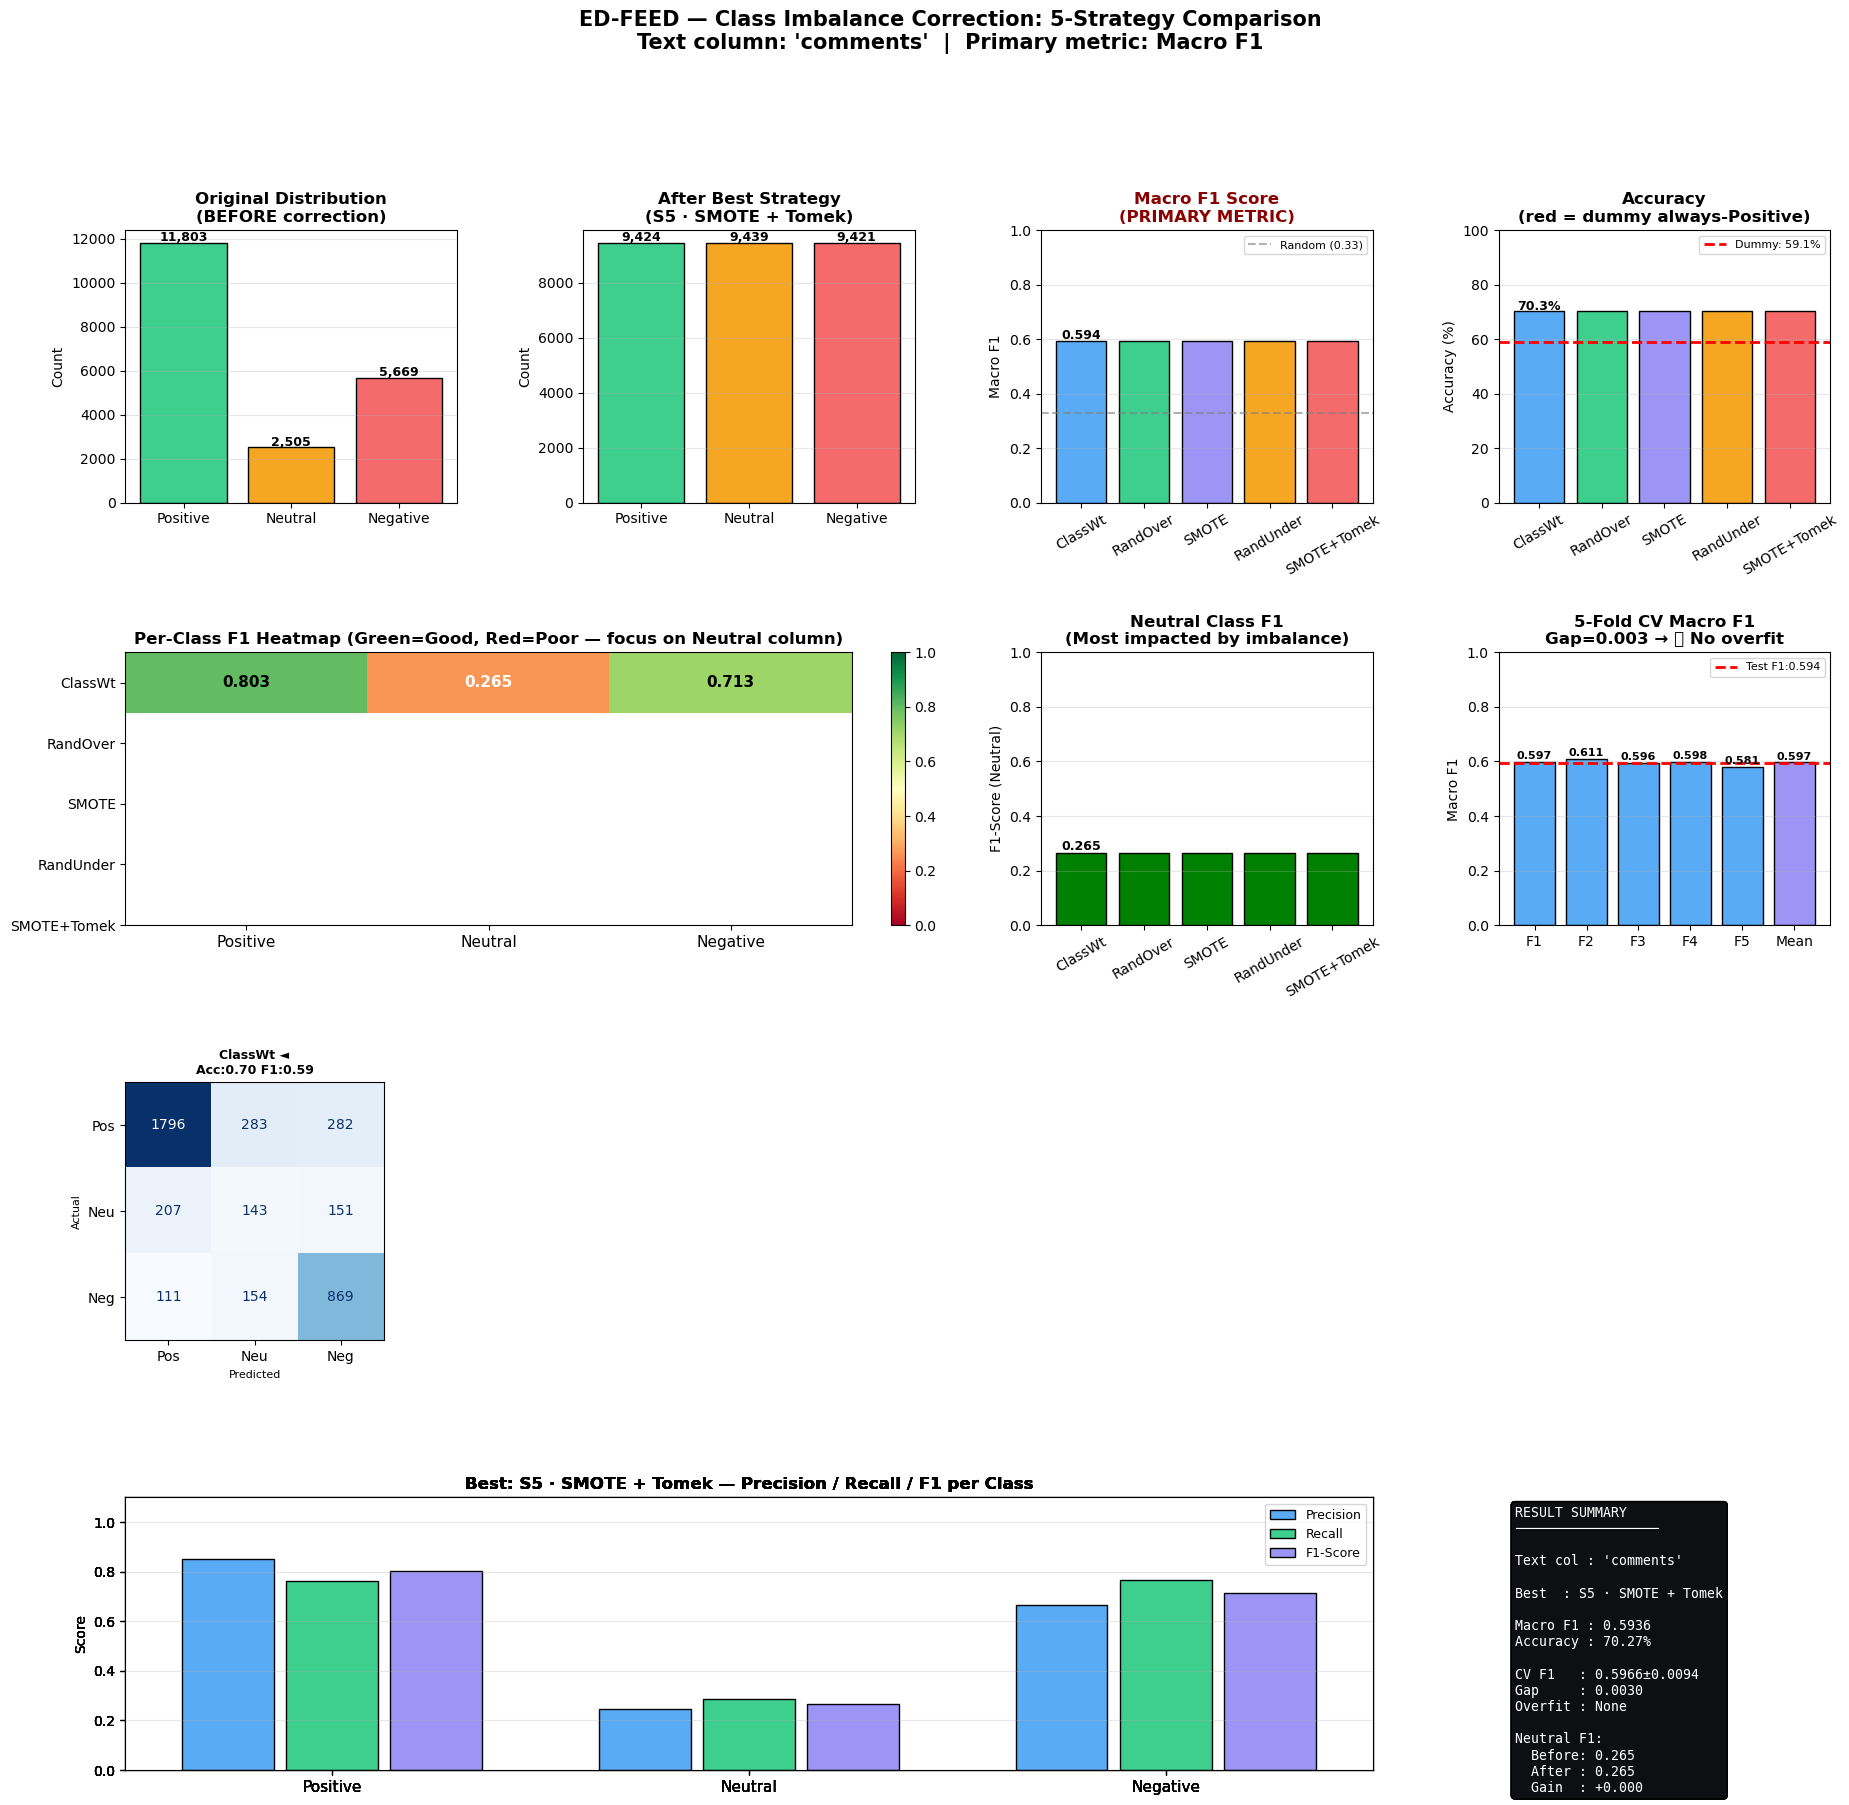

  Saved: imbalance_correction_results.png


In [ ]:
ax_pr = fig.add_subplot(gs[3,:3])
bst   = results[best_key]['report']
prec  = [bst[l]['precision'] for l in LABEL_ORDER]
rec   = [bst[l]['recall']    for l in LABEL_ORDER]
f1s   = [bst[l]['f1-score']  for l in LABEL_ORDER]
xp    = np.arange(len(LABEL_ORDER))
ax_pr.bar(xp-0.25, prec, 0.22, label='Precision', color='#5aabf5', edgecolor='black')
ax_pr.bar(xp,      rec,  0.22, label='Recall',    color='#3ecf8e', edgecolor='black')
ax_pr.bar(xp+0.25, f1s,  0.22, label='F1-Score',  color='#9d95f5', edgecolor='black')
ax_pr.set_title(f"Best: {results[best_key]['name']} — Precision / Recall / F1 per Class", fontweight='bold')
ax_pr.set_xticks(xp); ax_pr.set_xticklabels(LABEL_ORDER, fontsize=11)
ax_pr.set_ylabel("Score"); ax_pr.set_ylim([0,1.1]); ax_pr.legend(fontsize=9); ax_pr.grid(axis='y', alpha=0.3)
display(fig)
ax_txt = fig.add_subplot(gs[3,3]); ax_txt.axis('off')
nb4 = results['S5']['report']['Neutral']['f1-score']
naf = results[best_key]['report']['Neutral']['f1-score']
txt = (f"RESULT SUMMARY\n──────────────────\n\n"
       f"Text col : '{TEXT_COL}'\n\n"
       f"Best  : {results[best_key]['name']}\n\n"
       f"Macro F1 : {results[best_key]['macro_f1']:.4f}\n"
       f"Accuracy : {results[best_key]['accuracy']*100:.2f}%\n\n"
       f"CV F1   : {cv_f1_mean:.4f}±{cv_f1_std:.4f}\n"
       f"Gap     : {gap:.4f}\n"
       f"Overfit : {'None ' if gap<0.03 else 'Mild '}\n\n"
       f"Neutral F1:\n"
       f"  Before: {nb4:.3f}\n"
       f"  After : {naf:.3f}\n"
       f"  Gain  : {naf-nb4:+.3f}")
ax_txt.text(0.05, 0.97, txt, transform=ax_txt.transAxes, fontsize=9.5,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#0d0f12', alpha=0.9), color='white')
fig.savefig(f'{"C:/Users/TANZEEM/Desktop/ed-feed project/datasetpreprocessing/result_plot.png"}imbalance_correction_results.png', facecolor='white', edgecolor='none',dpi=300, bbox_inches='tight')
plt.show
print(f"  Saved: imbalance_correction_results.png")

 

In [ ]:
print(results.keys())

# STEP 10 — SAVE OUTPUTS

In [ ]:
base_path = "C:/Users/TANZEEM/Desktop/ed-feed project/datasetpreprocessing/"

In [ ]:
pd.DataFrame({'comments': X_test_raw.values,
              'true_label': y_test.values,
              'predicted_label': results[best_key]['y_pred'],
              'correct': (y_test.values == results[best_key]['y_pred']).astype(int)
              }).to_csv(f'{"C:/Users/TANZEEM/Desktop/ed-feed project/datasetpreprocessing/model1_corrected_predictions.csv"}', index=False)
print(f"   Saved: model1_corrected_predictions.csv")
 
pd.DataFrame([{'strategy': res['name'], 'accuracy': round(res['accuracy'],4),
               'macro_f1': round(res['macro_f1'],4), 'weighted_f1': round(res['wtd_f1'],4),
               'neutral_f1': round(res['report']['Neutral']['f1-score'],4),
               'positive_f1': round(res['report']['Positive']['f1-score'],4),
               'negative_f1': round(res['report']['Negative']['f1-score'],4),
               'neutral_precision': round(res['report']['Neutral']['precision'],4),
               'neutral_recall': round(res['report']['Neutral']['recall'],4),
               } for res in results.values()]
             ).to_csv(f'{"C:/Users/TANZEEM/Desktop/ed-feed project/datasetpreprocessing/imbalance_strategy_comparison.csv"}', index=False)
print(f"   Saved: imbalance_strategy_comparison.csv")
 

   Saved: model1_corrected_predictions.csv
   Saved: imbalance_strategy_comparison.csv


In [ ]:
save_path = "C:/Users/TANZEEM/Desktop/ed-feed project/datasetpreprocessing/"

In [ ]:
target_col = 'sentiment_label'
X_raw = df.drop(columns=[target_col])
y_raw = df[target_col]

In [ ]:
ros = RandomOverSampler(random_state=42)
X_balanced_raw, y_balanced_raw = ros.fit_resample(X_raw, y_raw)

In [ ]:
df_balanced_full = pd.DataFrame(X_balanced_raw, columns=X_raw.columns)
df_balanced_full[target_col] = y_balanced_raw

In [ ]:
df_balanced_full.to_csv(save_path + "balanced_edufeed_dataset_FINAL.csv", index=False)
df_balanced_full.to_excel(save_path + "balanced_edufeed_dataset_FINAL.xlsx", index=False, engine='openpyxl')